In [53]:
from model.model import PoseModel
import torch
from data.dataset import LinemodDataset

import cv2
import numpy as np

from utils.predictions import estimate_pose
from utils.visualization import show_all

# Loading the model

In [89]:
checkpoint_path="checkpoints/last.pth"

In [90]:
model = PoseModel(num_objects=15).to("cuda")

    # Carica checkpoint
checkpoint = torch.load(checkpoint_path, map_location="cuda")

    # Carica pesi
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

/home/raciard/.conda/envs/tp3d/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/raciard/.conda/envs/tp3d/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


PoseModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

# Loading the dataset

In [56]:
dataset_root = "datasets/Linemod_preprocessed/"

val_dataset = LinemodDataset(dataset_root, split='test')



folder_id: 2, sample_ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216

# Making a prediction and visualizing the corresponding 3d bb

sample number 2259, 


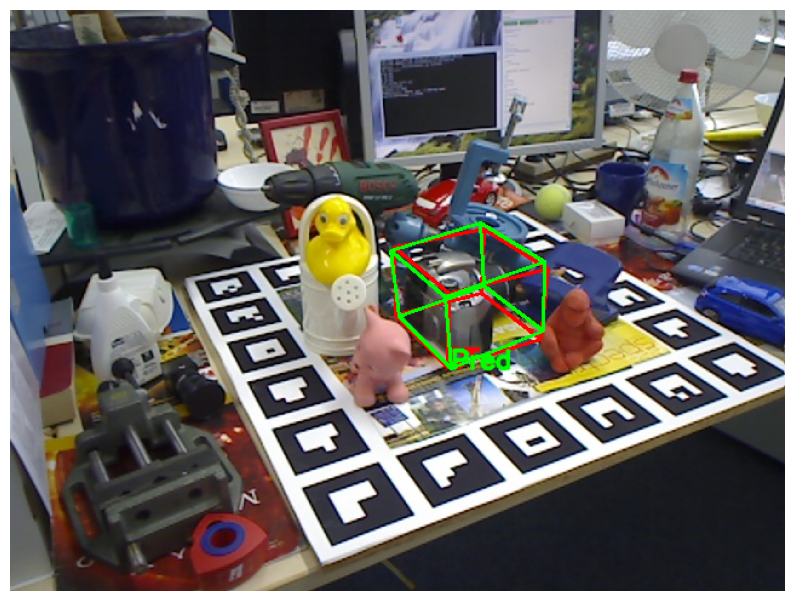

In [129]:
import random
random.seed()
sample_id =random.randint(0,len(val_dataset))
print(f"sample number {sample_id}, ")
pred_r, pred_t, _ = estimate_pose(model, val_dataset, sample_id)







show_all(val_dataset[sample_id], pred_r, pred_t)

In [130]:
val_dataset[4]

{'rgb': tensor([[[ 1.8208,  0.8618, -0.8335,  ...,  1.1015,  1.4612,  1.6667],
          [ 1.5297,  1.1187,  0.4166,  ...,  1.2214,  1.5297,  1.7180],
          [ 1.1358,  1.1529,  1.1872,  ...,  1.4269,  1.6153,  1.7352],
          ...,
          [ 1.5468,  1.5810,  1.6153,  ..., -1.5185, -1.5357, -1.5528],
          [ 1.5297,  1.5297,  1.5468,  ..., -1.4329, -1.5357, -1.5870],
          [ 1.5639,  1.5639,  1.5639,  ..., -1.4158, -1.5014, -1.5528]],
 
         [[ 2.2185,  1.2381, -0.4601,  ...,  0.4853,  0.6954,  0.8179],
          [ 1.9209,  1.5532,  0.9055,  ...,  0.4328,  0.6604,  0.7829],
          [ 1.5532,  1.6408,  1.7983,  ...,  0.4678,  0.6429,  0.7304],
          ...,
          [ 1.6933,  1.7283,  1.7808,  ..., -0.6877, -0.8452, -0.9153],
          [ 1.6057,  1.5882,  1.5532,  ..., -0.5651, -0.7752, -0.8978],
          [ 1.6057,  1.5357,  1.4132,  ..., -0.5126, -0.6702, -0.7577]],
 
         [[ 2.2914,  1.3154, -0.3927,  ...,  1.2108,  1.5420,  1.7337],
          [ 2.2391,  

In [100]:
import os

In [101]:
def get_3d_model_path(dataset_root, obj_id):
    print(obj_id)
    return os.path.join(dataset_root, 'models', f"obj_{obj_id+1:02d}.ply")

In [102]:
from metrics.add import compute_add, compute_add_percent, compute_adds, compute_adds_percent

In [103]:
import metrics.add 
importlib.reload(metrics.add)

<module 'metrics.add' from '/home/raciard/mldl/mldl_project/metrics/add.py'>

In [104]:
sample = val_dataset[sample_id]

In [105]:
model_path = get_3d_model_path(dataset_root,sample['obj_id'])

tensor(8)


In [106]:
compute_add(model_path, sample['rotation'], sample['translation'], pred_r, pred_t)

np.float64(29.531723487189318)

In [110]:
compute_add_percent(model_path, sample['rotation'], sample['translation'], pred_r,pred_t)

(np.float64(29.531723487189318),
 np.float64(81.03249466752837),
 np.float64(155.69640271370926))

In [111]:
compute_adds_percent(model_path, sample['rotation'], sample['translation'], pred_r,pred_t)

(np.float64(13.730540970064371),
 np.float64(91.18120860164525),
 np.float64(155.69640271370926))

In [112]:
from utils.refine_pose import refine_pose
import refiner.refiner
import utils.refine_pose
import importlib
importlib.reload(utils.refine_pose)
importlib.reload(refiner.refiner)

<module 'refiner.refiner' from '/home/raciard/mldl/mldl_project/refiner/refiner.py'>

In [113]:
refined_r, refined_t, losses = refine_pose(model_path, sample, pred_r, pred_t, num_iters=200)

[0/200] Loss: 0.000903
[1/200] Loss: 0.000867
[2/200] Loss: 0.000839
[3/200] Loss: 0.000820
[4/200] Loss: 0.000803
[5/200] Loss: 0.000792
[6/200] Loss: 0.000782
[7/200] Loss: 0.000781
[8/200] Loss: 0.000773
[9/200] Loss: 0.000770
[10/200] Loss: 0.000766
[11/200] Loss: 0.000752
[12/200] Loss: 0.000744
[13/200] Loss: 0.000736
[14/200] Loss: 0.000721
[15/200] Loss: 0.000702
[16/200] Loss: 0.000675
[17/200] Loss: 0.000639
[18/200] Loss: 0.000615
[19/200] Loss: 0.000583
[20/200] Loss: 0.000555
[21/200] Loss: 0.000529
[22/200] Loss: 0.000494
[23/200] Loss: 0.000455
[24/200] Loss: 0.000430
[25/200] Loss: 0.000405
[26/200] Loss: 0.000382
[27/200] Loss: 0.000360
[28/200] Loss: 0.000343
[29/200] Loss: 0.000330
[30/200] Loss: 0.000316
[31/200] Loss: 0.000299
[32/200] Loss: 0.000291
[33/200] Loss: 0.000278
[34/200] Loss: 0.000265
[35/200] Loss: 0.000259
[36/200] Loss: 0.000249
[37/200] Loss: 0.000239
[38/200] Loss: 0.000226
[39/200] Loss: 0.000223
[40/200] Loss: 0.000208
[41/200] Loss: 0.000205
[4

In [37]:
pred_r

array([[-0.56802977,  0.80760129, -0.15850029],
       [ 0.78383534,  0.47215749, -0.40332302],
       [-0.25088709, -0.35333761, -0.90122594]])

In [38]:
pred_t

array([[ 24.76424728],
       [-45.05147025],
       [964.33622522]])

In [39]:
sample['rotation']

tensor([[-0.5760,  0.8004, -0.1662],
        [ 0.7815,  0.4795, -0.3991],
        [-0.2398, -0.3598, -0.9017]])

In [40]:
sample['translation']

tensor([ 23.6810, -46.2806, 973.7670])

In [41]:
refined_r

tensor([[[-0.5673,  0.8060, -0.1692],
         [ 0.7867,  0.4696, -0.4007],
         [-0.2435, -0.3605, -0.9004]]], device='cuda:0', dtype=torch.float64)

In [42]:
refined_t

tensor([[ 0.0247, -0.0464,  0.9788]], device='cuda:0', dtype=torch.float64)

In [117]:
compute_adds_percent(model_path, sample['rotation'], sample['translation'], pred_r, pred_t)

(np.float64(13.730540970064371),
 np.float64(91.18120860164525),
 np.float64(155.69640271370926))

In [116]:
compute_adds_percent(model_path, sample['rotation'], sample['translation'], refined_r.cpu().detach().squeeze().numpy(), refined_t.cpu().detach() * 1000)

(np.float64(2.468765450863414),
 np.float64(98.4143721962524),
 np.float64(155.69640271370926))

In [45]:
r_ref = refined_r.cpu().detach().squeeze().numpy()
t_ref = refined_t.cpu().detach().numpy() * 1000

In [46]:
losses

[0.00040454723057337105,
 0.00042697490425780416,
 0.00046031500096432865,
 0.00046374599332921207,
 0.00044826854718849063,
 0.0004266172763891518,
 0.0004094727337360382,
 0.0003890569496434182,
 0.00038527598371729255,
 0.00037494831485673785,
 0.00036449654726311564,
 0.00035215786192566156,
 0.0003375074011273682,
 0.0003022057644557208,
 0.0002857685904018581,
 0.0002704228973016143,
 0.0002546710893511772,
 0.0002453266642987728,
 0.00023701779718976468,
 0.00022734918456990272,
 0.0002203784533776343,
 0.0002082867722492665,
 0.0001979125663638115,
 0.00018811238987836987,
 0.00018045175238512456,
 0.00017931066395249218,
 0.00017139075498562306,
 0.00016493404109496623,
 0.00016030611004680395,
 0.00015186757082119584,
 0.00014723505591973662,
 0.0001449216069886461,
 0.00013882345228921622,
 0.00013676811067853123,
 0.00013212760677561164,
 0.00012940980377607048,
 0.0001287847844650969,
 0.00012670698924921453,
 0.00012616693857125938,
 0.00012559934111777693,
 0.00012800341

In [51]:
add_perc_cum = 0
n_ok = 0
n_ok_per_obj = {}
n_tot_per_obj = dict()
for sample_id in range(len(val_dataset)):
    sample = val_dataset[sample_id]
    obj_id = int(sample['obj_id'])
    pred_r, pred_t, _ = estimate_pose(model, val_dataset, sample_id)
    model_path = get_3d_model_path(dataset_root, obj_id)
    refined_r, refined_t, losses = refine_pose(model_path, sample, pred_r, pred_t, num_iters=200)
    r_ref = refined_r.cpu().detach().squeeze().numpy()
    t_ref = refined_t.cpu().detach().numpy() * 1000
    add_abs, add_perc, _ = compute_add_percent(model_path, sample['rotation'], sample['translation'], r_ref, t_ref)
    add_perc_cum = add_perc_cum + add_perc
    if obj_id not in n_tot_per_obj:
        n_tot_per_obj[obj_id] = 0
        n_ok_per_obj[obj_id] = 0

    if add_perc > 90:
        n_ok+=1
        n_ok_per_obj[obj_id] += 1
    n_tot_per_obj[obj_id] +=1
    curr_perc = add_perc_cum / (sample_id + 1)
    curr_ok_perc = n_ok / (sample_id + 1) * 100
    curr_ok_perc_obj = (n_ok_per_obj[obj_id] if obj_id in n_ok_per_obj else 0) / n_tot_per_obj[obj_id] * 100

    print(f"Current add: {curr_perc}%")
    print(f"Current ok perc: {curr_ok_perc}")
    print(f"Current ok perc per obj {obj_id}: {curr_ok_perc_obj}")


    

4
[0/200] Loss: 0.000326
[1/200] Loss: 0.000287
[2/200] Loss: 0.000257
[3/200] Loss: 0.000261
[4/200] Loss: 0.000252
[5/200] Loss: 0.000256
[6/200] Loss: 0.000254
[7/200] Loss: 0.000256
[8/200] Loss: 0.000249
[9/200] Loss: 0.000232
[10/200] Loss: 0.000216
[11/200] Loss: 0.000208
[12/200] Loss: 0.000199
[13/200] Loss: 0.000200
[14/200] Loss: 0.000196
[15/200] Loss: 0.000197
[16/200] Loss: 0.000200
[17/200] Loss: 0.000198
[18/200] Loss: 0.000196
[19/200] Loss: 0.000192
[20/200] Loss: 0.000210
[21/200] Loss: 0.000204
[22/200] Loss: 0.000192
[23/200] Loss: 0.000196
[24/200] Loss: 0.000199
[25/200] Loss: 0.000201
[26/200] Loss: 0.000201
[27/200] Loss: 0.000198
[28/200] Loss: 0.000196
[29/200] Loss: 0.000192
[30/200] Loss: 0.000197
[31/200] Loss: 0.000202
[32/200] Loss: 0.000208
[33/200] Loss: 0.000202
[34/200] Loss: 0.000194
[35/200] Loss: 0.000196
[36/200] Loss: 0.000196
[37/200] Loss: 0.000196
[38/200] Loss: 0.000199
[39/200] Loss: 0.000200
[40/200] Loss: 0.000197
[41/200] Loss: 0.000196


AttributeError: 'NoneType' object has no attribute 'layout'

In [50]:
val_dataset[4]

{'rgb': tensor([[[ 0.7248,  0.7248,  0.1768,  ...,  0.5878,  0.8789,  0.8789],
          [ 0.7248,  0.7248,  0.1768,  ...,  0.5878,  0.8789,  0.8789],
          [ 0.4851,  0.4851, -0.0116,  ...,  0.6734,  0.9474,  0.9474],
          ...,
          [ 1.5982,  1.5982,  1.5297,  ..., -1.3302, -1.2959, -1.2959],
          [ 1.7352,  1.7352,  1.7009,  ..., -1.1247, -1.0562, -1.0562],
          [ 1.7352,  1.7352,  1.7009,  ..., -1.1247, -1.0562, -1.0562]],
 
         [[ 0.0826,  0.0826, -0.3550,  ...,  0.6429,  0.9405,  0.9405],
          [ 0.0826,  0.0826, -0.3550,  ...,  0.6429,  0.9405,  0.9405],
          [-0.2325, -0.2325, -0.3025,  ...,  0.7479,  1.0455,  1.0455],
          ...,
          [-0.6877, -0.6877, -0.0399,  ..., -0.1625, -0.1275, -0.1275],
          [-1.8782, -1.8782, -0.8803,  ..., -0.0224,  0.0476,  0.0476],
          [-1.8782, -1.8782, -0.8803,  ..., -0.0224,  0.0476,  0.0476]],
 
         [[-0.0790, -0.0790, -0.4101,  ...,  0.8622,  1.1585,  1.1585],
          [-0.0790, -

In [464]:
n_ok_per_obj

{4: 56,
 0: 80,
 12: 55,
 13: 39,
 14: 55,
 7: 47,
 8: 57,
 3: 52,
 9: 53,
 10: 31,
 11: 48,
 5: 51}

In [465]:
n_tot_per_obj

{4: 58,
 0: 89,
 12: 58,
 13: 42,
 14: 56,
 7: 47,
 8: 58,
 3: 53,
 9: 56,
 10: 47,
 11: 53,
 5: 51}